<img
    src="https://upload.wikimedia.org/wikipedia/commons/4/42/CNAM_Logo.svg"
    alt=""
    height="200px"
    width="200px"
    align=left
/>


<center> <br>
  <h1 style="color:#7c7979";>CSC217 - Projet guidé</h1>
</center>  

<center>
  <h2 style="color:#000000";>Optimisation</h2>
</center>

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random
import math

# Sujet et objectif du projet

L'objectif de ce projet est de trouver le minimum de la fonction objectif suivante :

$$ \mathcal{J} = 0.2 + x_1^2 + x_2^2 - 0.1 \cos(6 \pi x_1) - 0.1 \cos(6 \pi x_2)$$

La cellule ci-dessous définit la fonction $\mathcal{J}$ et affiche sa représentation graphique sous forme d'isocontours dans le plan $(x_1, x_2) \in [-1,1]^2$.

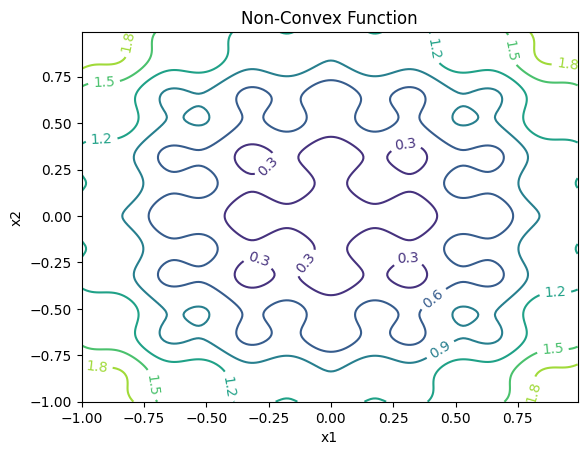

In [ ]:
# define objective function
def f(x):
    x1 = x[0]
    x2 = x[1]
    obj = 0.2 + x1**2 + x2**2 - 0.1*math.cos(6.0*3.1415*x1) - 0.1*math.cos(6.0*3.1415*x2)
    return obj

# Start location
x_start = [0.8, -0.5]

# Design variables at mesh points
i1 = np.arange(-1.0, 1.0, 0.01)
i2 = np.arange(-1.0, 1.0, 0.01)
x1m, x2m = np.meshgrid(i1, i2)
fm = np.zeros(x1m.shape)
for i in range(x1m.shape[0]):
    for j in range(x1m.shape[1]):
        fm[i][j] = 0.2 + x1m[i][j]**2 + x2m[i][j]**2 \
             - 0.1*math.cos(6.0*3.1415*x1m[i][j]) \
             - 0.1*math.cos(6.0*3.1415*x2m[i][j])

# Create a contour plot
plt.figure()

CS = plt.contour(x1m, x2m, fm)
# Label contours
plt.clabel(CS, inline=1, fontsize=10)
# Add some text to the plot
plt.title('Non-Convex Function')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

La recherche de cet optimum sera faite en utilisant l'algorithme "**simulated annealing**" expliqué ci-dessous :

#### Choix possibles pour la fonction $g$ de température :
* Fast : $T_k = T_0 \times e^{-k}$
* Exponentielle : $T_k = T_0 \times 0.95^k$
* Boltzmann : $T_k = \dfrac{T_0}{\log(k+1)}$
* Cauchy : $T_k = \dfrac{T_0}{k+1}$

In [ ]:
import math
from math import exp, pow,log

In [ ]:
def g(T0,k,function):
  if function== 'Fast':
    return T0*exp(-k)
  if function=='Exp':
    return T0*pow(0.95,k)
  if function== 'Boltz':
    return T0/log(k+1)
  elif function=='Cauchy':
    return T0/(k+1)

In [ ]:

def nouveau (x):
  x_p=[2,2]
  while(x_p[0]<-1 or x_p[0]>1 or x_p[1]<-1 or x_p[1]>1) :
    x_p=[x[0]+np.random.uniform(-1,1),x[1]+np.random.uniform(-1,1)]
  return x_p

# recherche uniforme  d'un x' autour de x sans sortir du domaine

In [ ]:

### Simulated annealing algorithm here

def simulated_annealing(kmax,T0,x0,function):
  history_x=[]
  history_y=[]
  k=1
  T=T0
  x=x0
  y = f(x)
  x_best, y_best = x, y
  while( k <= kmax) :
    history_x.append(x_best)
    history_y.append(y_best)
    x_p = nouveau(x)
    y_p= f(x_p)
    delta_y = y_p - y
    if (delta_y < 0 or np.random.rand() < exp(-delta_y / T)):
      x = x_p
      y = y_p
    if delta_y < 0 :
      x_best = x_p
      y_best = y_p

   # print("Fin Etape k=",k,"x_best:",x_best, "y_best:", y_best, "T=", T )

    if (T>0):
      last_T=T
      T  = g(T0, k,function)
      if (T<=0):
        T=last_T #Gestion de la température pour éviter les divisions par zero

    k = k + 1
  return x_best, y_best, history_x, history_y



x= [-0.048226500418462104, 0.03458940129167476]
y= 0.0625817458174485


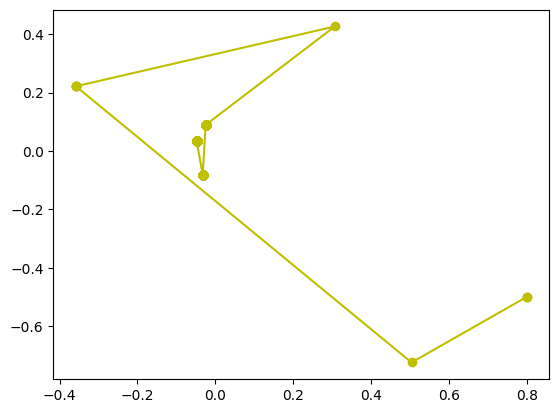

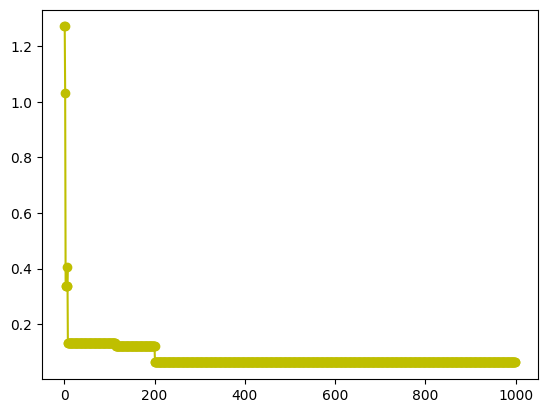

In [ ]:
#Premier test avec la fonction Fast et T0=10
T0=10
function= 'Fast'
kmax=1000
x=[]
x_best,y_best,x,y=simulated_annealing(kmax,T0,x_start,function)
x=np.array(x)
# print solution
print ("x=",x_best)
print ("y=",y_best)
plt.plot(x[:,0],x[:,1],'y-o')
plt.show()
plt.plot(y,'y-o')
plt.show()

x= [-0.03597413388720527, -0.0005250594426564614]
y= 0.02342123188127257


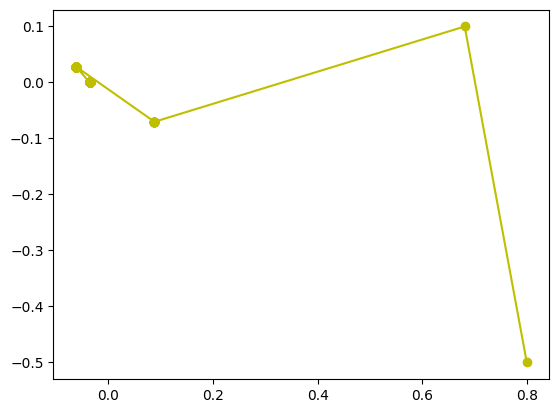

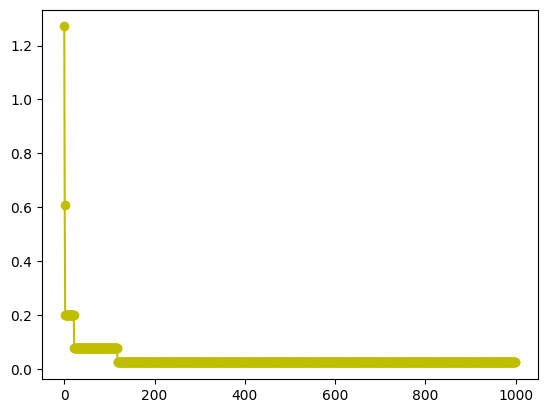

In [ ]:
#Fast et T0=1
T0=1
function= 'Fast'
kmax=1000
x=[]
x_best,y_best,x,y=simulated_annealing(kmax,T0,x_start,function)
x=np.array(x)
# print solution
print ("x=",x_best)
print ("y=",y_best)
plt.plot(x[:,0],x[:,1],'y-o')
plt.show()
plt.plot(y,'y-o')
plt.show()

x= [0.2242447613667582, 0.6151009977426076]
y= 0.6189713680580538


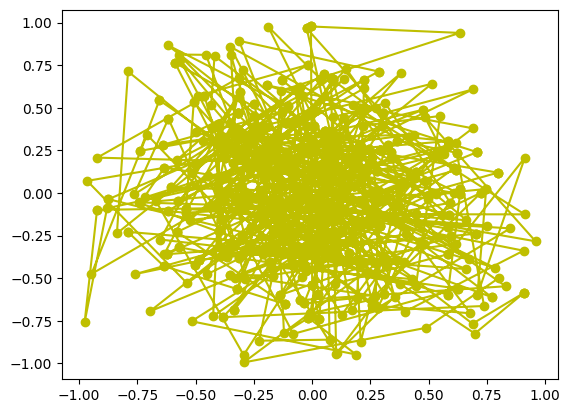

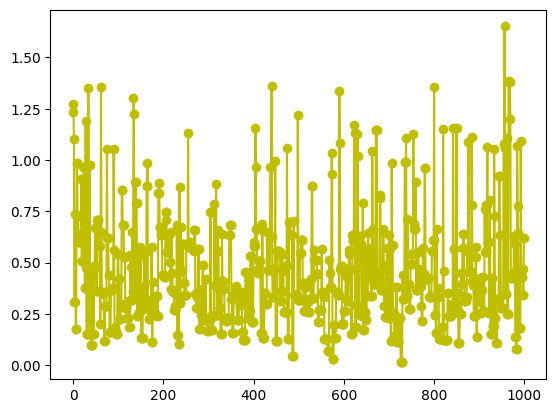

In [ ]:
#Boltz et T0=10
T0=10
function= 'Boltz'
kmax=1000
x=[]
x_best,y_best,x,y=simulated_annealing(kmax,T0,x_start,function)
x=np.array(x)
# print solution
print ("x=",x_best)
print ("y=",y_best)
plt.plot(x[:,0],x[:,1],'y-o')
plt.show()
plt.plot(y,'y-o')
plt.show()

x= [0.08826486915263776, 0.1469062194219839]
y= 0.33178953612197315


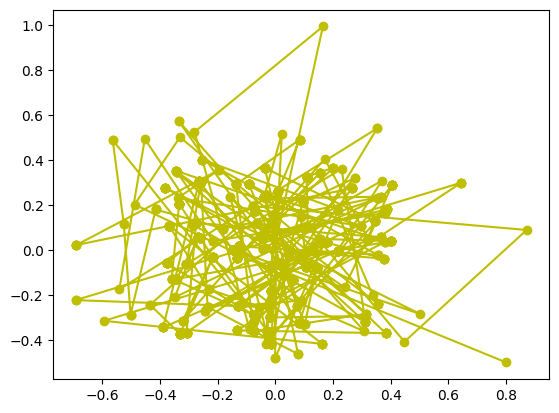

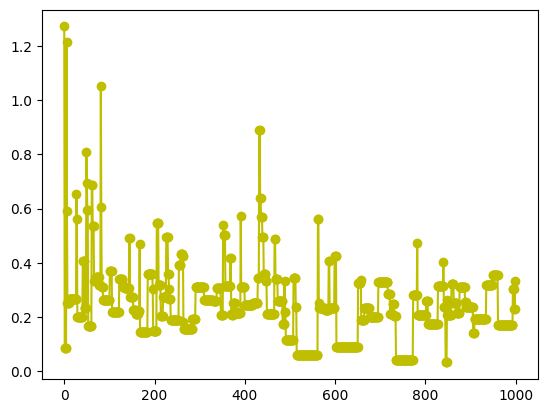

In [ ]:
#Boltz et T0=1
T0=1
function= 'Boltz'
kmax=1000
x=[]
x_best,y_best,x,y=simulated_annealing(kmax,T0,x_start,function)
x=np.array(x)
# print solution
print ("x=",x_best)
print ("y=",y_best)
plt.plot(x[:,0],x[:,1],'y-o')
plt.show()
plt.plot(y,'y-o')
plt.show()

x= [0.03427567606671866, -0.015988217755999123]
y= 0.026091060900984134


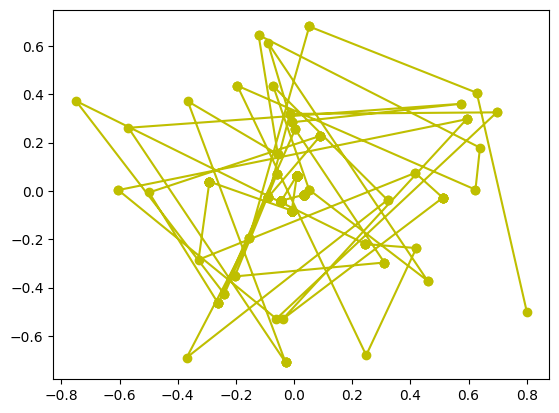

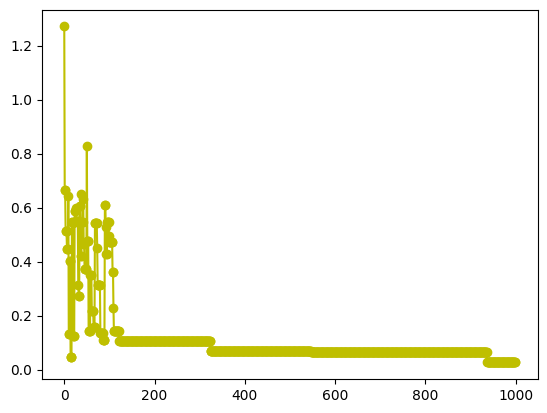

In [ ]:
#Exp et T0=0
T0=10
function= 'Exp'
kmax=1000
x=[]
x_best,y_best,x,y=simulated_annealing(kmax,T0,x_start,function)
x=np.array(x)
# print solution
print ("x=",x_best)
print ("y=",y_best)
plt.plot(x[:,0],x[:,1],'y-o')
plt.show()
plt.plot(y,'y-o')
plt.show()

x= [-0.018359251661569154, 0.013005629469203805]
y= 0.00942408538436268


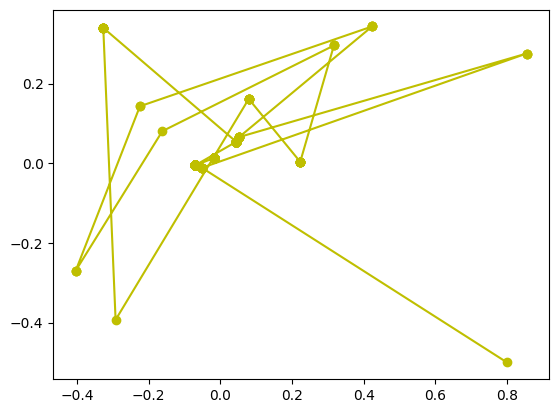

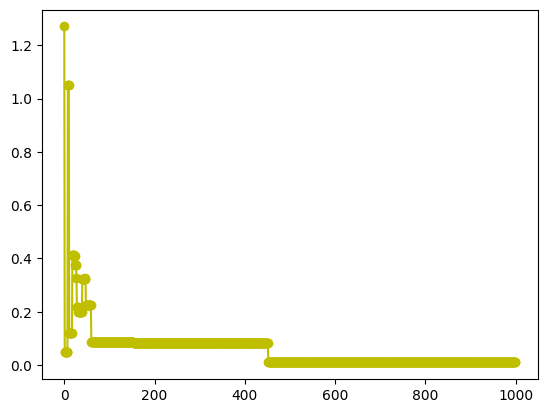

In [ ]:
#Exp et T0=1
T0=1
function= 'Exp'
kmax=1000
x=[]
x_best,y_best,x,y=simulated_annealing(kmax,T0,x_start,function)
x=np.array(x)
# print solution
print ("x=",x_best)
print ("y=",y_best)
plt.plot(x[:,0],x[:,1],'y-o')
plt.show()
plt.plot(y,'y-o')
plt.show()

x= [-0.012926306185919278, 0.018031093025034917]
y= 0.009165905604539087


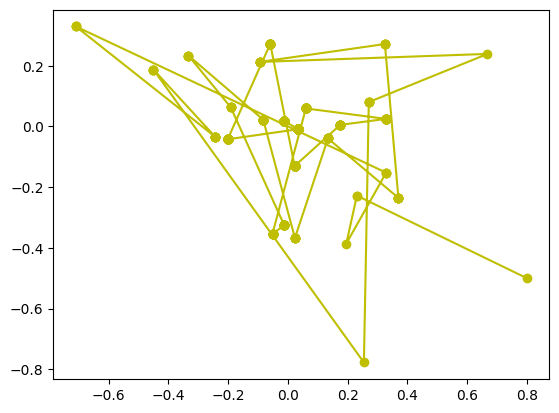

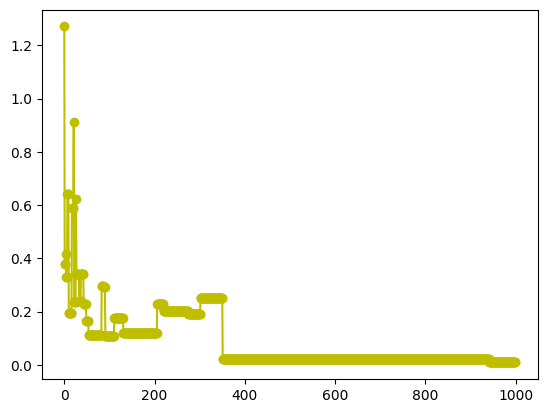

In [ ]:
#Cauchy T0=10
T0=10
function= 'Cauchy'
kmax=1000
x=[]
x_best,y_best,x,y=simulated_annealing(kmax,T0,x_start,function)
x=np.array(x)
# print solution
print ("x=",x_best)
print ("y=",y_best)
plt.plot(x[:,0],x[:,1],'y-o')
plt.show()
plt.plot(y,'y-o')
plt.show()

x= [-0.020496405435736387, 0.005202030231606258]
y= 0.008297941171762468


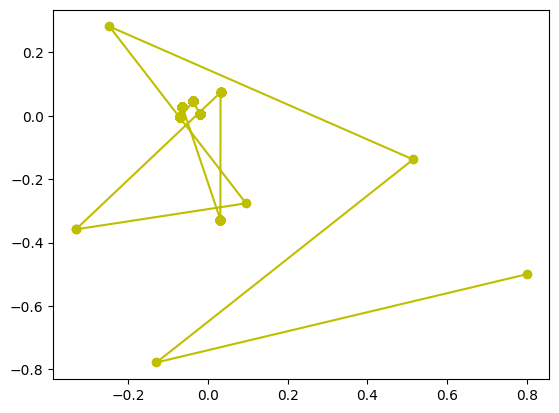

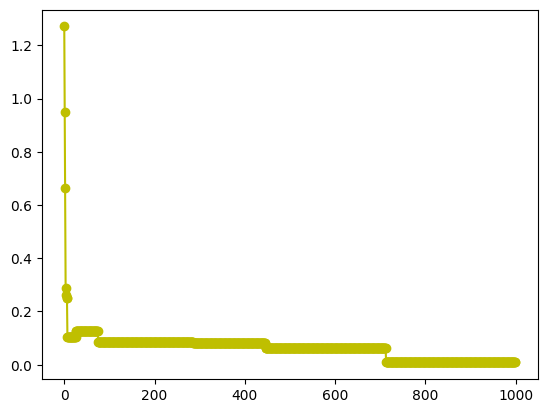

In [ ]:
#Cauchy T0=1
T0=1
function= 'Cauchy'
kmax=1000
x=[]
x_best,y_best,x,y=simulated_annealing(kmax,T0,x_start,function)
x=np.array(x)
# print solution
print ("x=",x_best)
print ("y=",y_best)
plt.plot(x[:,0],x[:,1],'y-o')
plt.show()
plt.plot(y,'y-o')
plt.show()

In [ ]:
x_start

[0.8, -0.5]

In [ ]:
def Boucle(kmax,T,X0,function):
  Y=[]
  x1=[]
  x2=[]
  for i in range(100):

    x_best,y_best,x,y=simulated_annealing(kmax,T,X0,function)
    Y.append(y_best)
    x1.append(x_best[0])
    x2.append(x_best[1])
  #print("moyenne y :",np.mean(Y))
  #print("moyenne x1 : ",np.mean(x1))
  #print("moyenne x2 : ",np.mean(x2))


  return [np.mean(x1),np.mean(x2)], np.mean(Y)


In [ ]:
x_mean, y_mean = Boucle(1000,10,x_start,'Fast')
print("moyenne y :",y_mean)
print("moyenne x1 : ",x_mean[0])
print("moyenne x2 : ",x_mean[1])


moyenne y : 0.021347343209252117
moyenne x1 :  -0.0006739625975596897
moyenne x2 :  0.0013849085110128412


Comparaison avec la méthode BasinHopping

In [ ]:
import scipy.optimize

In [ ]:

scipy.optimize.basinhopping(f, x_start, niter=1000, T=1.0)

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 1.6653345369377348e-16
                          x: [-2.825e-09  1.196e-09]
                        nit: 1000
      minimization_failures: 0
                       nfev: 42288
                       njev: 14096
 lowest_optimization_result:  message: Optimization terminated successfully.
                              success: True
                               status: 0
                                  fun: 1.6653345369377348e-16
                                    x: [-2.825e-09  1.196e-09]
                                  nit: 7
                                  jac: [ 1.732e-07  3.241e-07]
                             hess_inv: [[ 2.673e-02  1.557e-04]
                                        [ 1.557e-04  2.694e-02]]
                                 nfev: 39
                                 njev: 13

Fonction name= Fast
moyenne y : 0.02094095446622881
moyenne x1 :  0.001979747320113965
moyenne x2 :  -0.0026053411639226764
Fonction name= Exp
moyenne y : 0.019711005158509255
moyenne x1 :  -0.0019175912852254285
moyenne x2 :  0.004743192198484907
Fonction name= Boltz
moyenne y : 0.19706356160229244
moyenne x1 :  -0.008250080291356736
moyenne x2 :  0.018731363558964403
Fonction name= Cauchy
moyenne y : 0.021580799464615153
moyenne x1 :  0.0019097735573657415
moyenne x2 :  0.0051275458177395625


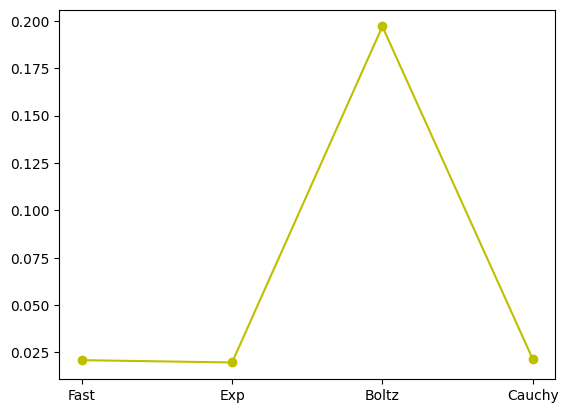

In [ ]:
Names=['Fast','Exp', 'Boltz','Cauchy']
Y_means=[]
for name in Names:
  print ("Fonction name=",name)
  x_mean, y_mean = Boucle(1000,1,x_start,name)
  print("moyenne y :",y_mean)
  print("moyenne x1 : ",x_mean[0])
  print("moyenne x2 : ",x_mean[1])
  Y_means.append(y_mean)
plt.plot(Names,Y_means,'y-o')
plt.show()

k_max= 10
moyenne y : 0.40164141678001963
moyenne x1 :  0.009265534259300236
moyenne x2 :  -0.0012103492349748812
k_max= 50
moyenne y : 0.41418287842048984
moyenne x1 :  0.022869811737541355
moyenne x2 :  0.026936023374551466
k_max= 100
moyenne y : 0.1956143915387988
moyenne x1 :  0.015106580402062164
moyenne x2 :  0.010517336530886354
k_max= 500
moyenne y : 0.03848698895395173
moyenne x1 :  -0.0018114169125374002
moyenne x2 :  -0.008206282774659792
k_max= 1000
moyenne y : 0.0181381594056455
moyenne x1 :  0.0033163613908539745
moyenne x2 :  0.004000897910298495
k_max= 2000
moyenne y : 0.012388889860889681
moyenne x1 :  0.0004970346185131969
moyenne x2 :  -0.0007680592418508336
k_max= 5000
moyenne y : 0.004578069881092476
moyenne x1 :  0.0015983229816826806
moyenne x2 :  0.00020198262945793965


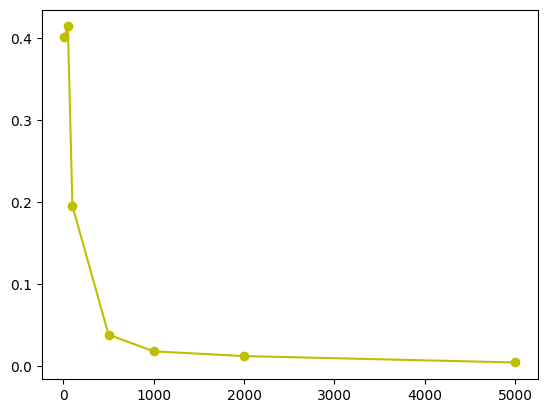

In [ ]:
k_max=[10,50,100,500,1000,2000,5000]
Y_means=[]
for k in k_max:
  print ("k_max=",k)
  x_mean, y_mean = Boucle(k,10,x_start,'Exp')
  print("moyenne y :",y_mean)
  print("moyenne x1 : ",x_mean[0])
  print("moyenne x2 : ",x_mean[1])
  Y_means.append(y_mean)
plt.plot(k_max,Y_means,'y-o')
plt.show()

T= 0.01
moyenne y : 0.004369276294221183
moyenne x1 :  -0.000897452335999045
moyenne x2 :  0.001055368830109511
T= 0.1
moyenne y : 0.004374414073004564
moyenne x1 :  0.0001717389113250678
moyenne x2 :  0.0011534164723758832
T= 1
moyenne y : 0.00406590977326465
moyenne x1 :  -0.0005935376866512687
moyenne x2 :  0.00011632197024744162
T= 10
moyenne y : 0.004563341398899956
moyenne x1 :  -0.00048646013709221283
moyenne x2 :  0.0010960324894130834
T= 50
moyenne y : 0.005631072071316812
moyenne x1 :  0.0007008309094210774
moyenne x2 :  -0.0003698983938356215
T= 100
moyenne y : 0.005042689159782915
moyenne x1 :  0.0004027456441182964
moyenne x2 :  0.0010401349726707875
T= 1000
moyenne y : 0.004278145994207816
moyenne x1 :  -0.0003888443521663798
moyenne x2 :  0.0003606530994531365


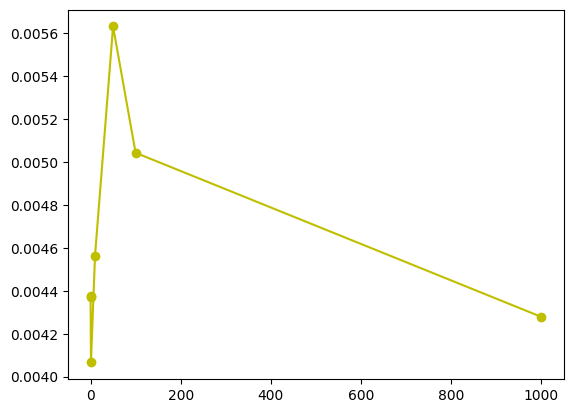

In [ ]:
Y_means=[]
T=[10e-3,0.1,1,10,50,100,1000]
for t in T:
  print ("T=",t)
  x_mean, y_mean=Boucle( 5000,t,x_start,'Exp')
  print("moyenne y :",y_mean)
  print("moyenne x1 : ",x_mean[0])
  print("moyenne x2 : ",x_mean[1])
  Y_means.append(y_mean)
plt.plot(T,Y_means,'y-o')
plt.show()